In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/spotify_clean.csv')
print(f"✅ Loaded: {df.shape}")

# Set MLflow tracking
mlflow.set_tracking_uri('file:../mlflow_runs')
mlflow.set_experiment('spotify_popularity_prediction')
print("✅ MLflow experiment set")

/Users/user/Documents/spotify_intelligence_copilot/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/18 15:52:53 INFO mlflow.tracking.fluent: Experiment with name 'spotify_popularity_prediction' does not exist. Creating a new experiment.


✅ Loaded: (113549, 27)
✅ MLflow experiment set


In [2]:
# Features for the neural network
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_min', 'explicit',
    'mood_score', 'dance_energy', 'acoustic_score',
    'genre_avg_popularity', 'artist_avg_popularity'
]

TARGET = 'popularity'

X = df[FEATURES].values
y = df[TARGET].values

# Train/val/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Convert to tensors
def to_tensors(X, y):
    return (torch.FloatTensor(X), torch.FloatTensor(y).unsqueeze(1))

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
print("✅ Data ready for training")

Train: (81755, 16) | Val: (9084, 16) | Test: (22710, 16)
✅ Data ready for training


In [3]:
class PopularityNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super(PopularityNet, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_model(hidden_dims, lr, dropout, epochs=50):
    model     = PopularityNet(len(FEATURES), hidden_dims, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

print("✅ Neural network architecture defined")
print(f"Input features: {len(FEATURES)}")

✅ Neural network architecture defined
Input features: 16


In [4]:
# We'll try 3 different architectures and track with MLflow

experiments = [
    {"hidden_dims": [64, 32],         "lr": 0.001, "dropout": 0.3, "name": "small_2layer"},
    {"hidden_dims": [128, 64, 32],    "lr": 0.001, "dropout": 0.3, "name": "medium_3layer"},
    {"hidden_dims": [256, 128, 64],   "lr": 0.0005,"dropout": 0.2, "name": "large_3layer"},
]

results = []

for exp in experiments:
    print(f"\n{'='*50}")
    print(f"Training: {exp['name']}")
    print('='*50)
    
    with mlflow.start_run(run_name=exp['name']):
        # Log parameters
        mlflow.log_param("hidden_dims",  str(exp['hidden_dims']))
        mlflow.log_param("learning_rate", exp['lr'])
        mlflow.log_param("dropout",       exp['dropout'])
        mlflow.log_param("features",      len(FEATURES))
        
        # Train
        model, train_losses, val_losses = train_model(
            exp['hidden_dims'], exp['lr'], exp['dropout']
        )
        
        # Evaluate on test set
        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).squeeze().numpy()
        
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)
        rmse = np.sqrt(np.mean((y_test - preds)**2))
        
        # Log metrics
        mlflow.log_metric("MAE",  round(mae, 4))
        mlflow.log_metric("R2",   round(r2, 4))
        mlflow.log_metric("RMSE", round(rmse, 4))
        
        # Log model
        mlflow.pytorch.log_model(model, "model")
        
        results.append({
            "name": exp['name'],
            "MAE": round(mae, 3),
            "R2":  round(r2, 3),
            "RMSE": round(rmse, 3)
        })
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  R2:   {r2:.3f}")
        print(f"  RMSE: {rmse:.3f}")

print("\n📊 All experiments complete!")
print(pd.DataFrame(results).to_string(index=False))


Training: small_2layer
Epoch  10 | Train Loss: 160.9107 | Val Loss: 127.2065
Epoch  20 | Train Loss: 157.9012 | Val Loss: 127.6427
Epoch  30 | Train Loss: 156.3605 | Val Loss: 126.3607
Epoch  40 | Train Loss: 156.5991 | Val Loss: 126.0145


2026/03/18 15:53:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 15:53:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch  50 | Train Loss: 155.9601 | Val Loss: 126.7591
  MAE:  6.346
  R2:   0.731
  RMSE: 11.606

Training: medium_3layer
Epoch  10 | Train Loss: 160.7902 | Val Loss: 127.3847
Epoch  20 | Train Loss: 158.0432 | Val Loss: 126.0413
Epoch  30 | Train Loss: 157.6729 | Val Loss: 126.2248
Epoch  40 | Train Loss: 157.5802 | Val Loss: 125.5739


2026/03/18 15:54:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 15:54:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch  50 | Train Loss: 157.3122 | Val Loss: 125.4727
  MAE:  6.248
  R2:   0.734
  RMSE: 11.543

Training: large_3layer
Epoch  10 | Train Loss: 144.2386 | Val Loss: 125.3098
Epoch  20 | Train Loss: 142.4581 | Val Loss: 125.3249
Epoch  30 | Train Loss: 140.4800 | Val Loss: 124.5081
Epoch  40 | Train Loss: 140.1753 | Val Loss: 124.7874


2026/03/18 15:55:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 15:55:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch  50 | Train Loss: 139.2547 | Val Loss: 124.2766
  MAE:  6.143
  R2:   0.736
  RMSE: 11.497

📊 All experiments complete!
         name   MAE    R2   RMSE
 small_2layer 6.346 0.731 11.606
medium_3layer 6.248 0.734 11.543
 large_3layer 6.143 0.736 11.497


In [5]:
import pickle, os

# Best model is the one with lowest MAE
best = min(results, key=lambda x: x['MAE'])
print(f"Best model: {best['name']}")
print(f"MAE: {best['MAE']} | R2: {best['R2']} | RMSE: {best['RMSE']}")

# Retrain best config
best_config = next(e for e in experiments if e['name'] == best['name'])
final_model, _, _ = train_model(
    best_config['hidden_dims'],
    best_config['lr'],
    best_config['dropout'],
    epochs=80
)

# Save model and scaler
os.makedirs('../models', exist_ok=True)
torch.save(final_model.state_dict(), '../models/popularity_model.pt')
torch.save({
    'hidden_dims': best_config['hidden_dims'],
    'dropout': best_config['dropout'],
    'input_dim': len(FEATURES),
    'features': FEATURES
}, '../models/model_config.pt')

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ Model saved to /models")
print("✅ Scaler saved to /models")

Best model: large_3layer
MAE: 6.143 | R2: 0.736 | RMSE: 11.497
Epoch  10 | Train Loss: 144.8335 | Val Loss: 126.3257
Epoch  20 | Train Loss: 142.2370 | Val Loss: 125.2005
Epoch  30 | Train Loss: 141.3668 | Val Loss: 124.2443
Epoch  40 | Train Loss: 139.6271 | Val Loss: 124.2831
Epoch  50 | Train Loss: 138.7898 | Val Loss: 124.5003
Epoch  60 | Train Loss: 138.9216 | Val Loss: 124.1059
Epoch  70 | Train Loss: 138.9757 | Val Loss: 123.8678
Epoch  80 | Train Loss: 138.2206 | Val Loss: 124.0818

✅ Model saved to /models
✅ Scaler saved to /models


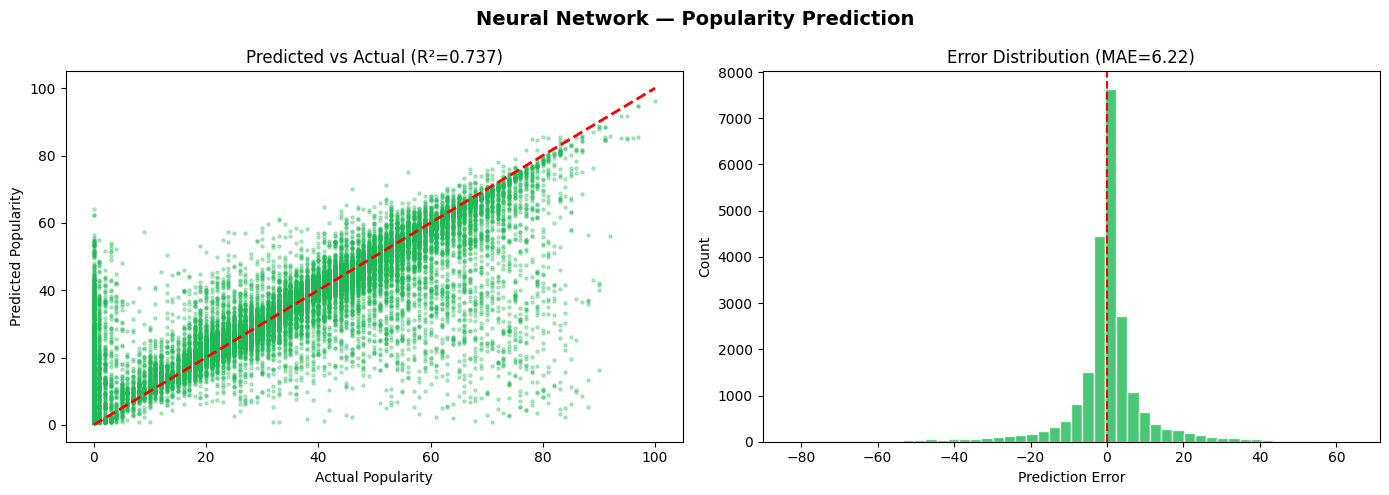


✅ Final Model Performance:
   MAE:  6.215
   R2:   0.737
   RMSE: 11.477


In [6]:
# Reload best model and plot predictions vs actual
config = torch.load('../models/model_config.pt')
final_model = PopularityNet(config['input_dim'], config['hidden_dims'], config['dropout'])
final_model.load_state_dict(torch.load('../models/popularity_model.pt'))
final_model.eval()

with torch.no_grad():
    preds = final_model(X_test_t).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network — Popularity Prediction', fontsize=14, fontweight='bold')

# Scatter plot
axes[0].scatter(y_test, preds, alpha=0.3, color='#1DB954', s=5)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Predicted vs Actual (R²={r2_score(y_test, preds):.3f})')

# Error distribution
errors = preds - y_test
axes[1].hist(errors, bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Error Distribution (MAE={mean_absolute_error(y_test, preds):.2f})')

plt.tight_layout()
plt.show()

print(f"\n✅ Final Model Performance:")
print(f"   MAE:  {mean_absolute_error(y_test, preds):.3f}")
print(f"   R2:   {r2_score(y_test, preds):.3f}")
print(f"   RMSE: {np.sqrt(np.mean((y_test-preds)**2)):.3f}")